# 第8章 计算机视觉深度学习入门

本章内容包括以下内容：
- 理解卷积神经网络
- 使用数据增强来降低过拟合
- 使用预训练的卷积神经网络进行特征提取
- 微调预训练的卷积神经网络

## 8.1 卷积神经网络入门

代码清单 8-1 实例化一个小型卷积神经网络

In [2]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPool2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

2025-02-18 10:10:54.416818: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2025-02-18 10:10:56.050549: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-02-18 10:10:56.054891: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-02-18 10:10:56.112195: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:927] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-18 10:10:56.112262: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce RTX 3060 Laptop GPU computeCapability: 8.6
coreClock: 1.425GHz coreCount: 30 deviceMemorySize: 6.00GiB deviceMemoryBandwidth: 312.97GiB/s
2025-02-18 10:10:56.112285: I tensorflow/stream_exec

重要的是，卷积神经网络接受的输入张量的型创维 (image_height, image_width, image_channels)。

代码清单 8-2 显示模型的概述信息

In [3]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 28, 28, 1)]       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 3, 3, 128)         73856     
_________________________________________________________________
flatten (Flatten)            (None, 1152)              0     

代码清单 8-23 在 MNIST 图像上训练卷积神经网络

In [4]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=5, batch_size=64)


2025-02-17 13:18:48.619400: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2025-02-17 13:18:48.619728: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 3293690000 Hz


Epoch 1/5


2025-02-17 13:18:48.930779: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2025-02-17 13:18:49.590480: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.7


938/938 [==============================] - 878s 7ms/step - loss: nan - accuracy: 0.0965
Epoch 2/5
938/938 [==============================] - 7s 8ms/step - loss: nan - accuracy: 0.0968
Epoch 3/5
938/938 [==============================] - 7s 8ms/step - loss: nan - accuracy: 0.0978
Epoch 4/5
938/938 [==============================] - 7s 8ms/step - loss: nan - accuracy: 0.0989
Epoch 5/5
938/938 [==============================] - 7s 8ms/step - loss: nan - accuracy: 0.0988


代码清单 8-4 评估卷积神经网络

In [1]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc: .3f}")

NameError: name 'model' is not defined

### 8.1.1 卷积运算

Dense 层从输入特征空间中学到的是全局模式，而卷积层学到的是局部模式。

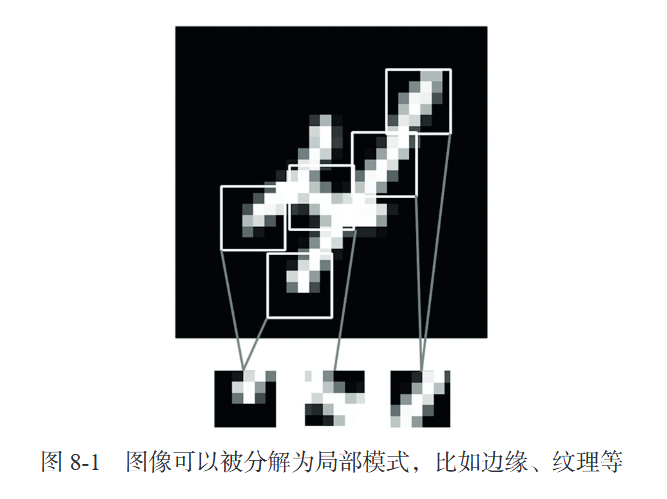

卷积神经网络的两个性质：
- **平移不变性**（translation invariant）。在图片右下角学到某个模式之后，卷积神经网络可以在任何位置识别出这个模式。
- **模式的空间层次结构**（spatial hierarchies of patterns）。第一个卷积层学习较小的局部模式(比如边缘)，第二个卷积层学习由第一层特征组成的更大的模式,以此类推。

一个形状为 (26, 26, 1) 的灰度图片作为输入卷积神经网络的**特征图**（feature map）,经运算后输出形状为 (26, 26, `filter`) 的**输出特征图**，`filter` 的每一层被称为一个**滤波器**（filter）。对应了从输入特征图中识别到的模式。

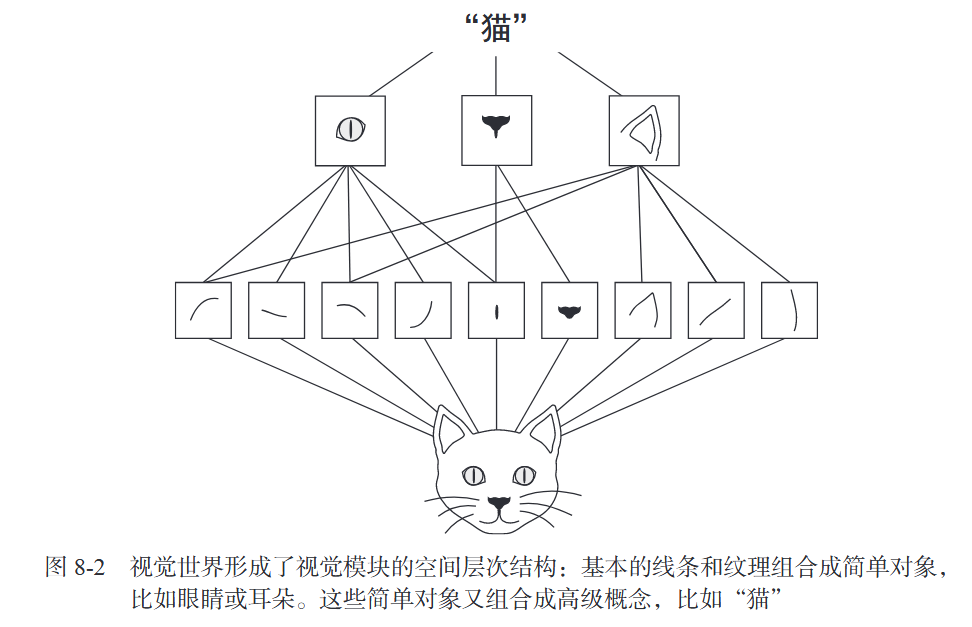

卷积由两个关键参数定义：

- **从输出层提取的图块尺寸**，通常采用 `3 x 3` 和 `5 x 5`。
- **输出特征图的深度**，卷积所计算的滤波器数量。

卷积的工作原理：

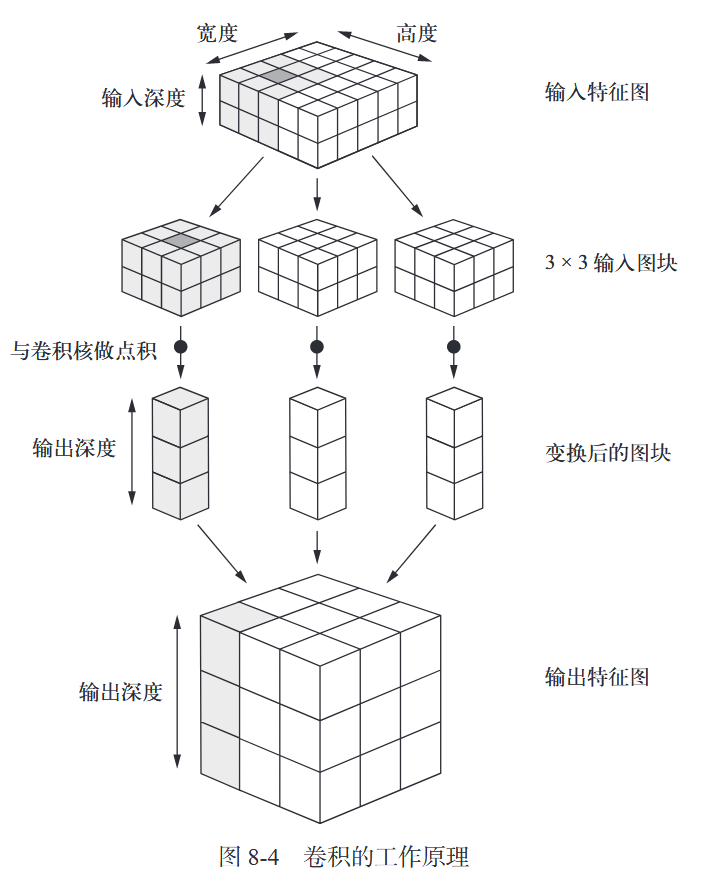

请注意，输出的宽度和高度可能会与输入的宽度和高度不同，原因有二：
- **边界效应**
- **步幅**

#### 1. 理解边界效应和填充

#### 2. 理解卷积步幅

### 8.1.2 最大汇聚运算

上面代码清单中的 `MaxPooling2D` 运用的算法叫**最大汇聚运算**，向 `MaxPooling2D` 中输入 26 x 26 的特征图，输出的特征图尺寸减半，得到 13 x 13 特征图。作用：主动对特征图进行下采样,与步进卷积类似。

代码清单 8-5 一个没有最大汇聚层、结构错误的卷积神经网络

In [ ]:
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x) outputs = layers.Dense(10, activation="softmax")(x)
model_no_max_pool = keras.Model(inputs=inputs, outputs=outputs)
model_no_max_pool.summary()

这种架构有以下两个问题：

- 不利于学习特征的空间级结构
- 最后一个特征图的参数过多

## 8.2 在小型数据集上从头开始训练一个卷积神经网络

### 8.2.1 深度学习对数据量很小的问题的适用性

样本足够”是相对于待训练模型的大小和深度而言的。只用几十个样本训练卷积神经网络来解决复杂问题是不可能的，但如果模型很小，并且做了很好的正则化，同时任务非常简单,那么几百个样本可能就足够了。

深度学习模型本质上具有很强的可复用性。比如，已有一个在大规模数据集上训练好的图像分类模型或语音转文本模型，只需稍作修改就能将其复用于完全不同的问题。

### 8.2.2 下载数据

数据集 Dogs vs. Cats 由 kaggle 提供，可以通过 API 进行下载。

需要在 Kaggle 官网注册账号，获取 API key 之后才能下载

代码清单 8-6 将图像复制到训练目录、验证目录和测试目录

In [5]:
import os, shutil, pathlib 
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small") 
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

SyntaxError: invalid syntax (3765364053.py, line 6)

### 8.2.3 构建模型

代码清单 8-7 为猫狗分类问题实例化一个小型卷积神经网络

In [6]:
from tensorflow import keras
from tensorflow.keras import layers 
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

AttributeError: module 'tensorflow.keras.layers' has no attribute 'Rescaling'

代码清单 8-8 配置模型，以进行训练

In [7]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

### 8.2.4 数据预处理

代码清单 8-9 使用 `image_dataset_from_directory()` 读取图像

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory 
train_dataset = image_dataset_from_directory( new_base_dir / "train", image_size=(180, 180), batch_size=32)
validation_dataset = image_dataset_from_directory( new_base_dir / "validation", image_size=(180, 180), batch_size=32)
test_dataset = image_dataset_from_directory( new_base_dir / "test", image_size=(180, 180), batch_size=32)

代码清单 8-10 显示 Dataset 生成的数据和标签的形状

代码清单 8-11 利用 Dataset 拟合模型

代码清单 8-12 绘制训练过程中的精度曲线和损失曲线

代码清单 8-13 在测试集上评估模型

### 8.2.5 使用数据增强

如果拥有无限的数据，模型能够观察到数据分布的所有内容，那么永远不会出现过拟合。数据增强是指从现有的训练样本中生成更多的训练数据，做法是利用一些能够生成可信图像的随机变换来增强(augment)样本。数据增强的目标是，模型在训练时不会两次查看完全相同的图片。这有助于模型观察到数据的更多内容，从而具有更强的泛化能力。



代码清单 8-14 定义一个数据增强代码块,以便将其添加到图像模型中

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2)
        ]
    )

这里只列出了几种可用的数据增强层。
- `RandomFlip("horizontal")`:将水平翻转应用于随机抽取的 50% 的图像。
- `RandomRotation(0.1)`:将输入图像在 [−10%, +10%] 的范围随机旋转(这个范围是相对于整个圆的比例,用角度表示的话,范围是 [−36° , +36° ])。
- `RandomZoom(0.2)`:放大或缩小图像,缩放比例在 [−20%, +20%] 范围内随机取值。

代码清单 8-15 随机显示几张增强后的训练图像

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

代码清单 8-16 定义一个包含数据增强和 dropout 的新卷积神经网络

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs) 
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

代码清单 8-17 训练一个正则化的卷积神经网络

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True, monitor="val_loss")
    ] 
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

代码清单 8-18 在测试集上评估模型

In [ ]:
test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

## 8.3 使用预训练模型

在小型图像数据集上做深度学习，一种常用且非常有效的方法是使用预训练模型。

### 8.3.1 使用预训练模型做特征提取

代码清单 8-19 将 VGG16 卷积基实例化

In [ ]:
conv_base = keras.applications.vgg16(
    weights="imagent",
    include_top=False,
    input_shape=(180, 180, 3)
)

这里向构造函数传入 3 个参数：
- `weights` 指定模型初始化的权重检查点
- `include_top` 指定是否包含密集连接分类器
- `input_shape` 是输入模型的图像张量的形状。

In [ ]:
conv_base.summary()


#### 1. 不适用数据增强的快速特征提取

代码清单 8-20 提取 VGG16 的特征和对应的标签

In [ ]:
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels) 
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

代码清单 8-21 定义并训练密集连接分类器

In [ ]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs) 
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"]) 
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
    ] 
history = model.fit(train_features, train_labels,
                    epochs=20,
                    validation_data=(val_features, val_labels),
                    callbacks=callbacks)

代码清单 8-22 绘制结果

In [ ]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()


#### 2. 使用数据增强的特征提取

代码清单 8-23 将 VGG16 卷积基实例化并冻结

In [ ]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False

代码清单 8-24 打印冻结前后的可训练权重列表

In [ ]:
conv_base.trainable = True
print("This is the number of trainable weights "
      "before freezing the cove base:", len(conv_base.trainable_weights))
conv_base.trainable = False
print("This is the number of trainable weights "
      "after freezing the conv base:", len(conv_base.trainable_weights))

代码清单 8-25 在卷积基上添加数据增强代码块和分类器

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        ]
    ) 
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])